## Cell 1 Imports & Data Loading

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

text_data_path = "../data/processed/cleaned_multilingual_text.csv"
if not os.path.exists(text_data_path):
    text_data_path = "../data/processed/synthetic_amharic_text.csv"

df_text = pd.read_csv(text_data_path)
print(f"Loaded Text Dataset shape: {df_text.shape}")
df_text.head()

Loaded Text Dataset shape: (26245, 7)


,statement,status,statement_amharic,cleaned_english,cleaned_amharic,en_word_count,am_word_count
0,Anyone else have symptoms much improved after ...,Bipolar,ሌላ ሰው የትዳር ጓደኛዬን ለቅቄ ከሄደ በኋላ ምልክቶቼ በጣም የተሻሻሉ ና...,anyone else have symptoms much improved after ...,ሌላ ሰው የትዳር ጓደኛዬን ለቅቄ ከሄደ በኋላ ምልክቶቼ በጣም የተሻሻሉ ና...,252,59
1,"I basicaly do not exist, sure feels that way. ...",Suicidal,እኔ በመሠረቱ አልኖርም ፣ በእርግጥም እንደዚህ ይሰማኛል ። ምንም ጓደኞች...,"i basicaly do not exist, sure feels that way. ...",እኔ በመሠረቱ አልኖርም ፣ በእርግጥም እንደዚህ ይሰማኛል ። ምንም ጓደኞች...,65,71
2,Finding a sense of self It's like one minute I...,Personality_disorder,አንድ ደቂቃ ውስጥ አንድ ሰው ነኝ እና በሚቀጥለው ጊዜ ሙሉ በሙሉ የተለየ...,finding a sense of self its like one minute im...,አንድ ደቂቃ ውስጥ አንድ ሰው ነኝ እና በሚቀጥለው ጊዜ ሙሉ በሙሉ የተለየ...,58,43
3,Putting into words what were just tangles in m...,Anxiety,በአንጎሌ ውስጥ የተጨናነቁ ነገሮችን በቃላት መናገር ቀናተኛ ጭንቀት አለብ...,putting into words what were just tangles in m...,በአንጎሌ ውስጥ የተጨናነቁ ነገሮችን በቃላት መናገር ቀናተኛ ጭንቀት አለብ...,167,59
4,Anxiety makes me worry about my public image s...,Anxiety,ጭንቀት ስለ ህዝባዊ ምስሌ በጣም ያሳስበኛል... በጣም... በጣም... በ...,anxiety makes me worry about my public image s...,ጭንቀት ስለ ህዝባዊ ምስሌ በጣም ያሳስበኛል... በጣም... በጣም... በ...,75,46


## Cell 2 Label Balance & Word Count Distribution

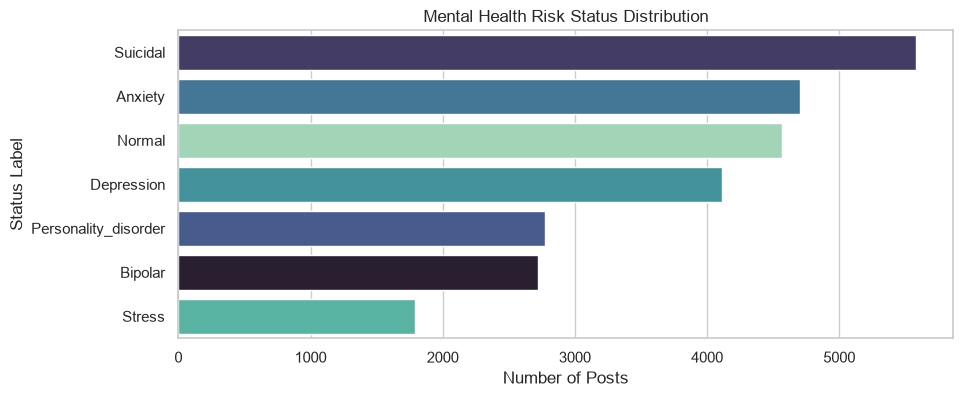

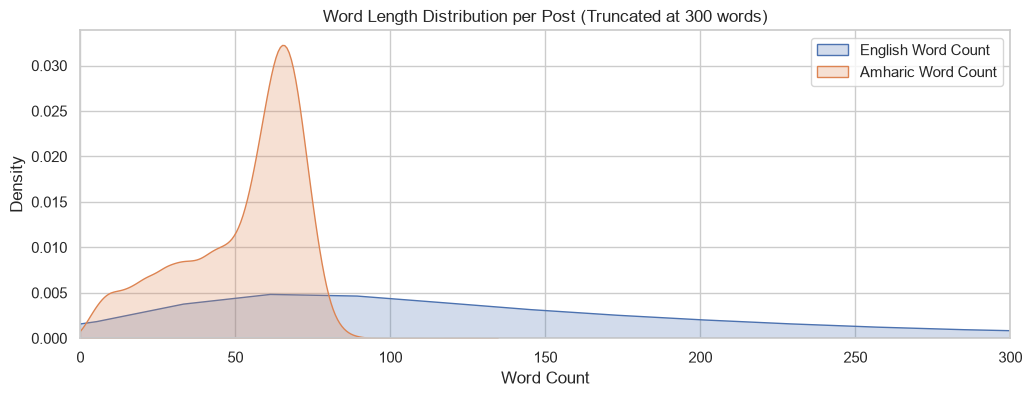

In [24]:
# Standardize column name references
status_col = "status" if "status" in df_text.columns else "Status"
statement_col = "statement" if "statement" in df_text.columns else "Statement"

# Plot Class Distribution (Fixing Seaborn warning)
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df_text, 
    y=status_col, 
    hue=status_col, 
    order=df_text[status_col].value_counts().index, 
    palette="mako", 
    legend=False
)
plt.title("Mental Health Risk Status Distribution")
plt.xlabel("Number of Posts")
plt.ylabel("Status Label")
plt.show()

# Access column using correct lowercase name
statement_col = 'statement' if 'statement' in df_text.columns else 'cleaned_english'
amharic_col = 'statement_amharic' if 'statement_amharic' in df_text.columns else 'cleaned_amharic'

df_text[statement_col] = df_text[statement_col].fillna("").astype(str)
df_text[amharic_col] = df_text[amharic_col].fillna("").astype(str)

df_text["en_word_count"] = df_text[statement_col].apply(lambda x: len(x.split()) if x else 0)
df_text["am_word_count"] = df_text[amharic_col].apply(lambda x: len(x.split()) if x else 0)

# Plot Word Count Distributions
plt.figure(figsize=(12, 4))
sns.kdeplot(df_text["en_word_count"], label="English Word Count", fill=True)
sns.kdeplot(df_text["am_word_count"], label="Amharic Word Count", fill=True)

plt.xlim(0, 300)
plt.title("Word Length Distribution per Post (Truncated at 300 words)")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.legend()
plt.show()

## Cell 3 Translation Integrity & Missing Value Inspection

In [25]:
# Audit missing translations or empty strings
print("--- Data Cleanliness Audit ---")
print("Null Values Count:\n", df_text.isnull().sum())

# Inspect sample English-to-Amharic translation pairs
if "Statement" in df_text.columns and "Statement_Amharic" in df_text.columns:
    sample_df = df_text[["Statement", "Statement_Amharic", status_col]].head(3)
    for idx, row in sample_df.iterrows():
        print(f"\n--- Sample {idx + 1} [{row[status_col]}] ---")
        print("EN:", row["Statement"][:120], "...")
        print("AM:", row["Statement_Amharic"][:120], "...")

--- Data Cleanliness Audit ---
Null Values Count:
 statement            0
status               0
statement_amharic    0
cleaned_english      0
cleaned_amharic      0
en_word_count        0
am_word_count        0
dtype: int64


In [26]:
# Identify correct column names regardless of letter casing
statement_col = 'statement' if 'statement' in df_text.columns else 'cleaned_english'
amharic_col = 'statement_amharic' if 'statement_amharic' in df_text.columns else 'cleaned_amharic'

print("--- Text Dataset Quality Audit ---")
print(f"Total Rows: {len(df_text)}")
print(f"Duplicate English Statements: {df_text[statement_col].duplicated().sum()}")
print(f"Missing English Statements: {(df_text[statement_col] == '').sum()}")
print(f"Missing Amharic Translations: {(df_text[amharic_col] == '').sum()}")

# Clean duplicates and empty entries dynamically
df_text_clean = df_text.drop_duplicates(subset=[statement_col]).copy()
df_text_clean = df_text_clean[df_text_clean[statement_col].str.strip() != ""]
print(f"Cleaned Dataset Shape: {df_text_clean.shape}")

--- Text Dataset Quality Audit ---
Total Rows: 26245
Duplicate English Statements: 0
Missing English Statements: 0
Missing Amharic Translations: 0
Cleaned Dataset Shape: (26245, 7)
